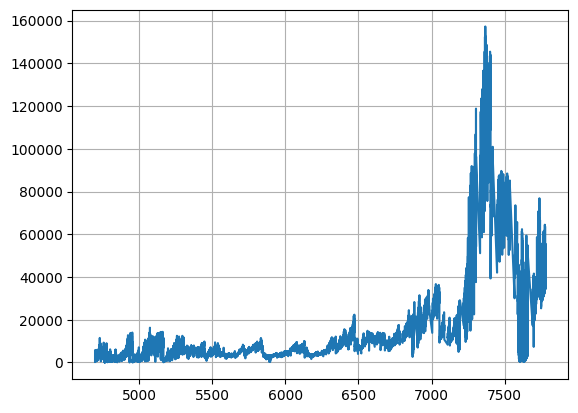

In [181]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
data = np.genfromtxt("R_Cam.spec")
# data = data[np.where((data[:, 0] >= 7450) & (data[:, 0] <= 7530))]
plt.plot(data[:, 0], data[:, 1])
plt.grid(True)

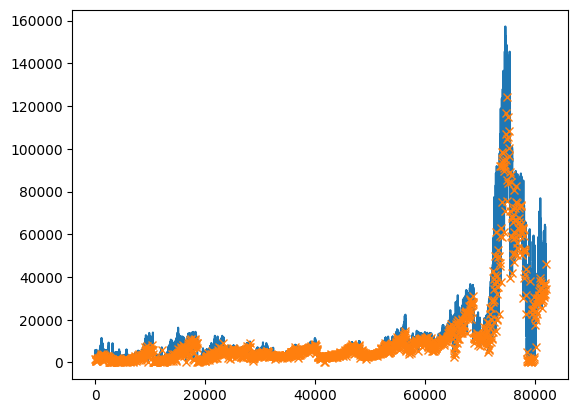

In [182]:

from scipy.signal import find_peaks
x = data[:, 1]
peaks, _ = find_peaks(-x, distance=40)
plt.plot(x)
plt.plot(peaks, x[peaks], "x")

In [183]:
detect_lines = data[peaks]

In [184]:
detect_lines

array([[ 4698.5682,  1384.    ],
       [ 4700.3907,   862.    ],
       [ 4701.7055,  1351.    ],
       ...,
       [ 7777.6658, 36479.    ],
       [ 7780.4266, 34481.    ],
       [ 7782.4595, 46161.    ]], shape=(1502, 2))

In [111]:
# fit_lines = np.genfromtxt("lines.txt", skip_header=1, dtype=str)

In [112]:
import pandas as pd

In [174]:
fit_lines = pd.read_csv("lines.txt", sep="\s+")
fit_lines

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_125395/1008066571.py:1: SyntaxWarning: invalid escape sequence '\s'
  fit_lines = pd.read_csv("lines.txt", sep="\s+")


,element,atomic_number,wavelength,loggf
Fe,II,26.0,5001.953,0.916
Ni,II,28.0,5003.414,0.656
Dy,I,66.0,5003.867,0.392
Fe,II,26.0,5004.188,0.504
Y,I,39.0,5006.962,0.133
...,...,...,...,...
Fe,II,26.0,7471.729,0.336
Rh,I,45.0,7475.734,0.210
Ru,I,44.0,7485.754,0.060
Mn,II,25.0,7491.593,0.106


In [114]:
wavelenght_fit = np.array(fit_lines['wavelength'].to_numpy(), dtype=float)

In [175]:
print(len(wavelenght_fit))
print(len(detect_lines))

1249
33


In [116]:
global_diff = []

In [117]:
for i in range(len(detect_lines)):
    indiv_diff = []
    for j in range(len(wavelenght_fit)):
        indiv_diff.append(detect_lines[i] - wavelenght_fit[j])
    global_diff.append(indiv_diff)
        

Тестовые данные:
Истинное красное смещение: 0.001234
Количество теоретических линий: 10
Количество наблюдаемых линий: 8

РЕЗУЛЬТАТЫ ПОИСКА СМЕЩЕНИЯ СПЕКТРА
Красное смещение (z):      0.00122811
Лучевая скорость:          368.18 км/с
Количество совпадений:     6
Оценка качества:           0.767
Высота пика гистограммы:   3

СОВПАВШИЕ ЛИНИИ:
  1. λ_obs=  657.0948  λ_theor=  656.2800  Δ=0.008822  отн.огр=1.34e-05
  2. λ_obs=  486.7285  λ_theor=  486.1300  Δ=0.001479  отн.огр=3.04e-06
  3. λ_obs=  434.5921  λ_theor=  434.0500  Δ=0.009022  отн.огр=2.08e-05
  4. λ_obs=  397.5151  λ_theor=  397.0100  Δ=0.017547  отн.огр=4.42e-05
  5. λ_obs=  384.0109  λ_theor=  383.5400  Δ=0.000082  отн.огр=2.15e-07
  6. λ_obs=  377.5230  λ_theor=  377.0600  Δ=0.000120  отн.огр=3.19e-07


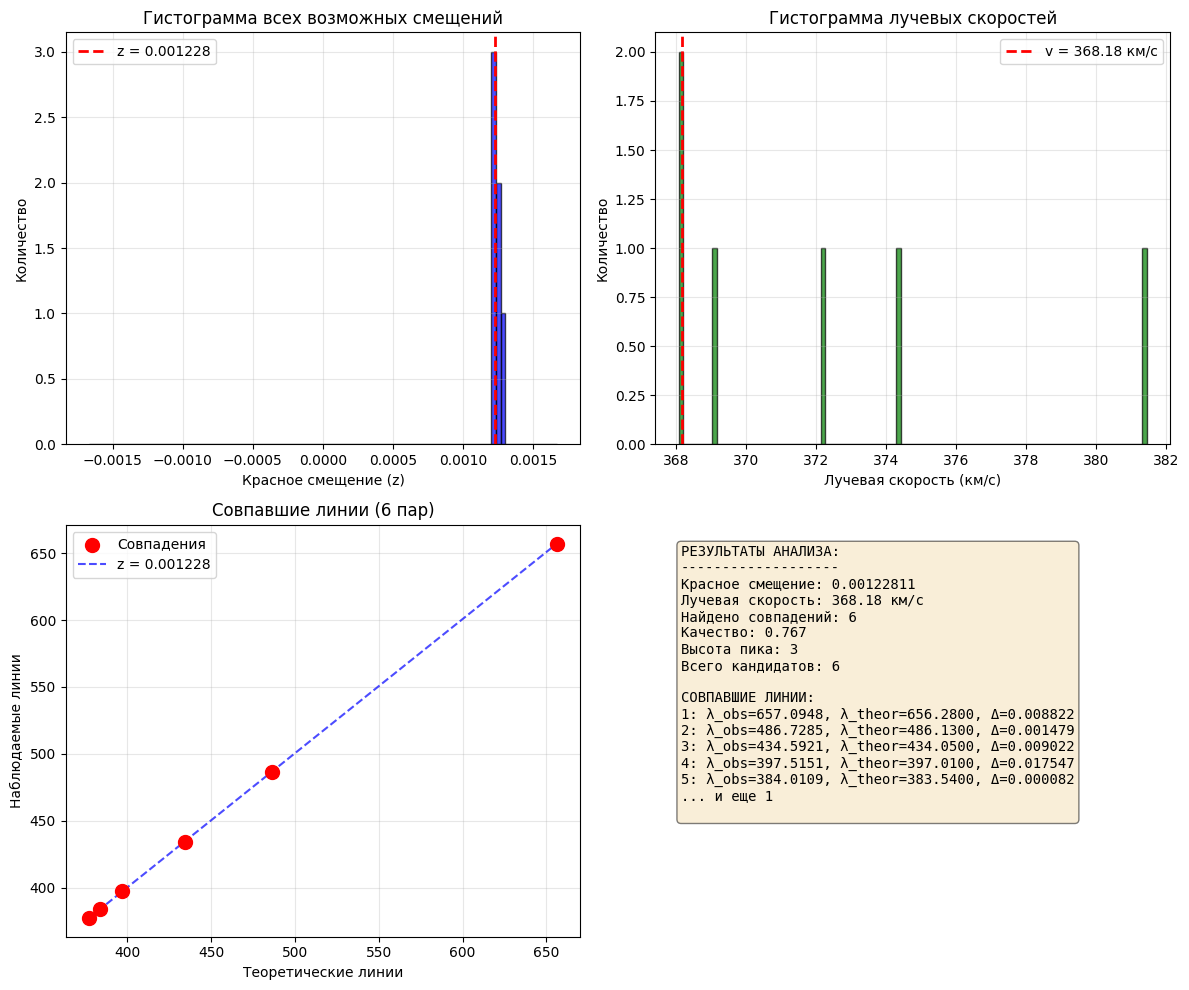

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from typing import Tuple, List, Optional
import warnings

class SpectralShiftFinder:
    def __init__(self, 
                 observed_lines: np.ndarray,
                 theoretical_lines: np.ndarray,
                 velocity_range: Optional[Tuple[float, float]] = None,
                 search_range: Optional[Tuple[float, float]] = None):
        """
        Инициализация поиска смещения спектральных линий методом Hough-преобразования.
        
        Parameters:
        -----------
        observed_lines : np.ndarray
            Наблюдаемые положения линий (в нм, Å или любых линейных единицах)
        theoretical_lines : np.ndarray
            Теоретические положения линий (в тех же единицах)
        velocity_range : Tuple[float, float], optional
            Диапазон лучевых скоростей в км/с для поиска (по умолчанию ±1000 км/с)
        search_range : Tuple[float, float], optional
            Диапазон смещения в относительных единицах (z) для поиска
        """
        self.observed_lines = np.array(observed_lines).flatten()
        self.theoretical_lines = np.array(theoretical_lines).flatten()
        
        if velocity_range is not None:
            # Преобразуем диапазон скоростей в красное смещение (z)
            c = 299792.458  # км/с
            z_min = velocity_range[0] / c
            z_max = velocity_range[1] / c
            self.search_range = (z_min, z_max)
        elif search_range is not None:
            self.search_range = search_range
        else:
            # По умолчанию ищем в диапазоне ±1000 км/с
            self.search_range = (-1000/299792.458, 1000/299792.458)
        
        self.results = {}
        
    def _calculate_all_shifts(self) -> np.ndarray:
        """
        Вычисляет все возможные смещения для каждой пары (наблюдаемая, теоретическая).
        
        Returns:
        --------
        np.ndarray: Все вычисленные смещения z
        """
        all_shifts = []
        
        # Для каждой наблюдаемой линии и каждой теоретической линии
        for obs in self.observed_lines:
            for theor in self.theoretical_lines:
                # Вычисляем красное смещение z = Δλ/λ = (λ_obs - λ_theor)/λ_theor
                if theor != 0:
                    z = obs / theor - 1
                    
                    # Фильтруем по диапазону поиска
                    if self.search_range[0] <= z <= self.search_range[1]:
                        all_shifts.append(z)
        
        return np.array(all_shifts)
    
    def _calculate_all_velocities(self) -> np.ndarray:
        """
        Вычисляет все возможные лучевые скорости.
        
        Returns:
        --------
        np.ndarray: Все вычисленные лучевые скорости в км/с
        """
        all_velocities = []
        c = 299792.458  # км/с
        
        for obs in self.observed_lines:
            for theor in self.theoretical_lines:
                if theor != 0:
                    # v = c * (λ_obs/λ_theor - 1)
                    v = c * (obs / theor - 1)
                    
                    # Преобразуем search_range в диапазон скоростей
                    v_min = c * self.search_range[0]
                    v_max = c * self.search_range[1]
                    
                    if v_min <= v <= v_max:
                        all_velocities.append(v)
        
        return np.array(all_velocities)
    
    def find_shift_hough(self, 
                         bins: int = 200,
                         smoothing: float = 0.1,
                         min_peaks: int = 3,
                         refine_iterations: int = 3) -> dict:
        """
        Основной метод поиска смещения методом Hough-преобразования.
        
        Parameters:
        -----------
        bins : int
            Количество бинов для гистограммы
        smoothing : float
            Параметр сглаживания для KDE (0 = нет сглаживания)
        min_peaks : int
            Минимальное количество наблюдений в пике
        refine_iterations : int
            Количество итераций уточнения
        
        Returns:
        --------
        dict: Результаты с найденными параметрами
        """
        # 1. Вычисляем все возможные смещения
        all_shifts = self._calculate_all_shifts()
        all_velocities = self._calculate_all_velocities()
        
        if len(all_shifts) == 0:
            raise ValueError("Не найдено ни одного смещения в заданном диапазоне. "
                           "Попробуйте расширить search_range.")
        
        # 2. Строим гистограмму смещений
        hist, bin_edges = np.histogram(all_shifts, bins=bins, 
                                        range=self.search_range, 
                                        density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # 3. Находим пики в гистограмме
        peak_indices = self._find_peaks(hist, min_height=min_peaks)
        
        if len(peak_indices) == 0:
            warnings.warn("Не найдено значимых пиков. Возвращаю наилучшее значение.")
            peak_indices = [np.argmax(hist)]
        
        # 4. Уточняем положение пика с помощью KDE
        refined_shifts = []
        for idx in peak_indices:
            peak_shift = bin_centers[idx]
            refined_shift = self._refine_peak(all_shifts, peak_shift, 
                                            refine_iterations, smoothing)
            refined_shifts.append(refined_shift)
        
        # 5. Выбираем наилучший пик (по высоте гистограммы)
        best_idx = peak_indices[np.argmax(hist[peak_indices])]
        best_shift = refined_shifts[np.argmax(hist[peak_indices])]
        best_velocity = 299792.458 * best_shift
        
        # 6. Оцениваем качество совпадения
        quality = self._evaluate_match_quality(all_shifts, best_shift, hist)
        
        # 7. Находим конкретные совпадающие линии
        matched_pairs = self._find_matched_pairs(best_shift)
        
        # 8. Сохраняем результаты
        self.results = {
            'redshift': best_shift,
            'velocity_km_s': best_velocity,
            'matched_pairs': matched_pairs,
            'matched_count': len(matched_pairs),
            'total_candidates': len(all_shifts),
            'peak_height': hist[best_idx],
            'quality_score': quality,
            'all_shifts': all_shifts,
            'all_velocities': all_velocities,
            'histogram': (hist, bin_centers),
            'alternative_peaks': refined_shifts
        }
        
        return self.results
    
    def _find_peaks(self, hist: np.ndarray, min_height: int = 3) -> List[int]:
        """
        Находит пики в гистограмме.
        
        Parameters:
        -----------
        hist : np.ndarray
            Гистограмма
        min_height : int
            Минимальная высота пика
        
        Returns:
        --------
        List[int]: Индексы пиков
        """
        peaks = []
        n = len(hist)
        
        for i in range(1, n-1):
            if (hist[i] > hist[i-1] and 
                hist[i] > hist[i+1] and 
                hist[i] >= min_height):
                peaks.append(i)
        
        return peaks
    
    def _refine_peak(self, 
                    shifts: np.ndarray, 
                    initial_guess: float,
                    iterations: int,
                    smoothing: float) -> float:
        """
        Уточняет положение пика с помощью KDE.
        
        Parameters:
        -----------
        shifts : np.ndarray
            Все вычисленные смещения
        initial_guess : float
            Начальное приближение
        iterations : int
            Количество итераций уточнения
        smoothing : float
            Параметр сглаживания
        
        Returns:
        --------
        float: Уточненное значение смещения
        """
        current_guess = initial_guess
        
        for _ in range(iterations):
            # Окно вокруг текущего предположения
            window = 0.05  # ±5% относительного диапазона
            window_size = (self.search_range[1] - self.search_range[0]) * window
            
            mask = (shifts >= current_guess - window_size) & \
                   (shifts <= current_guess + window_size)
            
            if np.sum(mask) > 0:
                if smoothing > 0 and len(shifts[mask]) > 1:
                    # Используем KDE для уточнения
                    kernel = stats.gaussian_kde(shifts[mask], bw_method=smoothing)
                    
                    # Ищем максимум KDE в окрестности
                    x = np.linspace(current_guess - window_size/2, 
                                   current_guess + window_size/2, 
                                   1000)
                    y = kernel(x)
                    current_guess = x[np.argmax(y)]
                else:
                    # Просто медиана
                    current_guess = np.median(shifts[mask])
            
        return current_guess
    
    def _evaluate_match_quality(self, 
                               all_shifts: np.ndarray, 
                               best_shift: float,
                               hist: np.ndarray) -> float:
        """
        Оценивает качество найденного совпадения.
        
        Returns:
        --------
        float: Оценка качества от 0 до 1
        """
        # Ширина окна для подсчета совпадений (0.5% от диапазона)
        window = (self.search_range[1] - self.search_range[0]) * 0.005
        
        # Количество смещений в окне вокруг лучшего значения
        in_window = np.sum((all_shifts >= best_shift - window) & 
                          (all_shifts <= best_shift + window))
        
        # Общее количество смещений
        total = len(all_shifts)
        
        # Высота пика относительно среднего
        peak_height = np.max(hist)
        avg_height = np.mean(hist)
        
        # Комбинированная оценка
        quality1 = in_window / total if total > 0 else 0
        quality2 = min(peak_height / (avg_height + 1), 1)  # Ограничиваем 1
        
        return 0.7 * quality1 + 0.3 * quality2
    
    def _find_matched_pairs(self, redshift: float, tolerance: float = 0.001) -> List[Tuple]:
        """
        Находит конкретные пары линий, совпадающие при данном красном смещении.
        
        Parameters:
        -----------
        redshift : float
            Красное смещение
        tolerance : float
            Допуск для совпадения (относительный)
        
        Returns:
        --------
        List[Tuple]: Список пар (наблюдаемая, теоретическая, разница)
        """
        matched_pairs = []
        
        for obs in self.observed_lines:
            # Теоретическая линия, соответствующая наблюдению при данном z
            theor_expected = obs / (1 + redshift)
            
            # Ищем ближайшую теоретическую линию
            differences = np.abs(self.theoretical_lines - theor_expected)
            min_idx = np.argmin(differences)
            
            # Проверяем, попадает ли в допуск
            rel_error = differences[min_idx] / theor_expected
            if rel_error <= tolerance:
                matched_pairs.append({
                    'observed': obs,
                    'theoretical': self.theoretical_lines[min_idx],
                    'difference': differences[min_idx],
                    'relative_error': rel_error
                })
        
        return matched_pairs
    
    def plot_results(self, figsize=(12, 10)):
        """
        Визуализация результатов.
        
        Parameters:
        -----------
        figsize : tuple
            Размер фигуры
        """
        if not self.results:
            raise ValueError("Сначала запустите find_shift_hough()")
        
        fig = plt.figure(figsize=figsize)
        
        # 1. Гистограмма смещений
        ax1 = plt.subplot(2, 2, 1)
        hist, bin_centers = self.results['histogram']
        ax1.bar(bin_centers, hist, width=bin_centers[1]-bin_centers[0], 
                alpha=0.7, color='blue', edgecolor='black')
        ax1.axvline(self.results['redshift'], color='red', linestyle='--', 
                   linewidth=2, label=f'z = {self.results["redshift"]:.6f}')
        ax1.set_xlabel('Красное смещение (z)')
        ax1.set_ylabel('Количество')
        ax1.set_title('Гистограмма всех возможных смещений')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Гистограмма скоростей
        ax2 = plt.subplot(2, 2, 2)
        velocities = self.results['all_velocities']
        v_bins = np.linspace(np.min(velocities), np.max(velocities), 100)
        ax2.hist(velocities, bins=v_bins, alpha=0.7, color='green', edgecolor='black')
        ax2.axvline(self.results['velocity_km_s'], color='red', linestyle='--', 
                   linewidth=2, label=f'v = {self.results["velocity_km_s"]:.2f} км/с')
        ax2.set_xlabel('Лучевая скорость (км/с)')
        ax2.set_ylabel('Количество')
        ax2.set_title('Гистограмма лучевых скоростей')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. Совпадающие линии
        ax3 = plt.subplot(2, 2, 3)
        matched_pairs = self.results['matched_pairs']
        if matched_pairs:
            obs_matched = [p['observed'] for p in matched_pairs]
            theor_matched = [p['theoretical'] for p in matched_pairs]
            
            ax3.scatter(theor_matched, obs_matched, color='red', s=100, 
                       label='Совпадения', zorder=3)
            
            # Линия идеального соответствия со смещением
            x_range = np.array([min(theor_matched), max(theor_matched)])
            y_range = x_range * (1 + self.results['redshift'])
            ax3.plot(x_range, y_range, 'b--', alpha=0.7, 
                    label=f'z = {self.results["redshift"]:.6f}')
            
            ax3.set_xlabel('Теоретические линии')
            ax3.set_ylabel('Наблюдаемые линии')
            ax3.set_title(f'Совпавшие линии ({len(matched_pairs)} пар)')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        
        # 4. Информация
        ax4 = plt.subplot(2, 2, 4)
        ax4.axis('off')
        
        info_text = (
            f"РЕЗУЛЬТАТЫ АНАЛИЗА:\n"
            f"-------------------\n"
            f"Красное смещение: {self.results['redshift']:.8f}\n"
            f"Лучевая скорость: {self.results['velocity_km_s']:.2f} км/с\n"
            f"Найдено совпадений: {self.results['matched_count']}\n"
            f"Качество: {self.results['quality_score']:.3f}\n"
            f"Высота пика: {self.results['peak_height']}\n"
            f"Всего кандидатов: {self.results['total_candidates']}\n"
        )
        
        # Добавляем информацию о совпавших линиях
        if matched_pairs:
            info_text += f"\nСОВПАВШИЕ ЛИНИИ:\n"
            for i, pair in enumerate(matched_pairs[:5]):  # Показываем первые 5
                info_text += (f"{i+1}: λ_obs={pair['observed']:.4f}, "
                            f"λ_theor={pair['theoretical']:.4f}, "
                            f"Δ={pair['difference']:.6f}\n")
            if len(matched_pairs) > 5:
                info_text += f"... и еще {len(matched_pairs) - 5}\n"
        
        ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes,
                fontfamily='monospace', verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    def print_summary(self):
        """Выводит краткое текстовое резюме результатов."""
        if not self.results:
            print("Результаты еще не вычислены. Запустите find_shift_hough()")
            return
        
        print("=" * 60)
        print("РЕЗУЛЬТАТЫ ПОИСКА СМЕЩЕНИЯ СПЕКТРА")
        print("=" * 60)
        print(f"Красное смещение (z):      {self.results['redshift']:.8f}")
        print(f"Лучевая скорость:          {self.results['velocity_km_s']:.2f} км/с")
        print(f"Количество совпадений:     {self.results['matched_count']}")
        print(f"Оценка качества:           {self.results['quality_score']:.3f}")
        print(f"Высота пика гистограммы:   {self.results['peak_height']}")
        print("=" * 60)
        
        if self.results['matched_pairs']:
            print("\nСОВПАВШИЕ ЛИНИИ:")
            for i, pair in enumerate(self.results['matched_pairs'][:10]):  # Ограничим вывод
                print(f"{i+1:3d}. λ_obs={pair['observed']:10.4f}  "
                      f"λ_theor={pair['theoretical']:10.4f}  "
                      f"Δ={pair['difference']:8.6f}  "
                      f"отн.огр={pair['relative_error']:.2e}")


# Пример использования
def example_usage():
    """
    Пример использования класса для поиска смещения спектра.
    """
    # Создадим тестовые данные
    np.random.seed(42)
    
    # Истинное красное смещение
    true_z = 0.001234  # ~370 км/с
    
    # Теоретические линии (например, линии водорода в нм)
    theoretical_lines = np.array([
        656.28,  # Hα
        486.13,  # Hβ
        434.05,  # Hγ
        410.17,  # Hδ
        397.01,  # Hε
        388.90,  # Hζ
        383.54,  # Hη
        379.79,  # Hθ
        377.06,  # Hι
        375.02   # Hκ
    ])
    
    # Создаем наблюдаемые линии с истинным смещением
    # Берем только некоторые линии + шум
    selected_indices = [0, 1, 2, 4, 6, 8]  # Выбираем некоторые линии
    observed_lines = theoretical_lines[selected_indices] * (1 + true_z)
    
    # Добавляем небольшой шум измерения
    noise = np.random.normal(0, 0.01, len(observed_lines))
    observed_lines += noise
    
    # Добавляем несколько случайных линий (выбросы)
    n_random = 2
    random_lines = np.random.uniform(380, 650, n_random)
    observed_lines = np.concatenate([observed_lines, random_lines])
    
    print(f"Тестовые данные:")
    print(f"Истинное красное смещение: {true_z:.6f}")
    print(f"Количество теоретических линий: {len(theoretical_lines)}")
    print(f"Количество наблюдаемых линий: {len(observed_lines)}")
    print()
    
    # Создаем объект для поиска смещения
    finder = SpectralShiftFinder(
        observed_lines=observed_lines,
        theoretical_lines=theoretical_lines,
        velocity_range=(-500, 500)  # Ищем в диапазоне ±500 км/с
    )
    
    # Запускаем поиск
    results = finder.find_shift_hough(
        bins=100,
        smoothing=0.1,
        min_peaks=2,
        refine_iterations=3
    )
    
    # Выводим результаты
    finder.print_summary()
    
    # Визуализируем
    finder.plot_results()
    
    return results


# Если запускаем как скрипт
if __name__ == "__main__":
    # Пример использования
    results = example_usage()

Красное смещение: -0.0002688312912581463
Скорость: -80.5935935935936 км/с


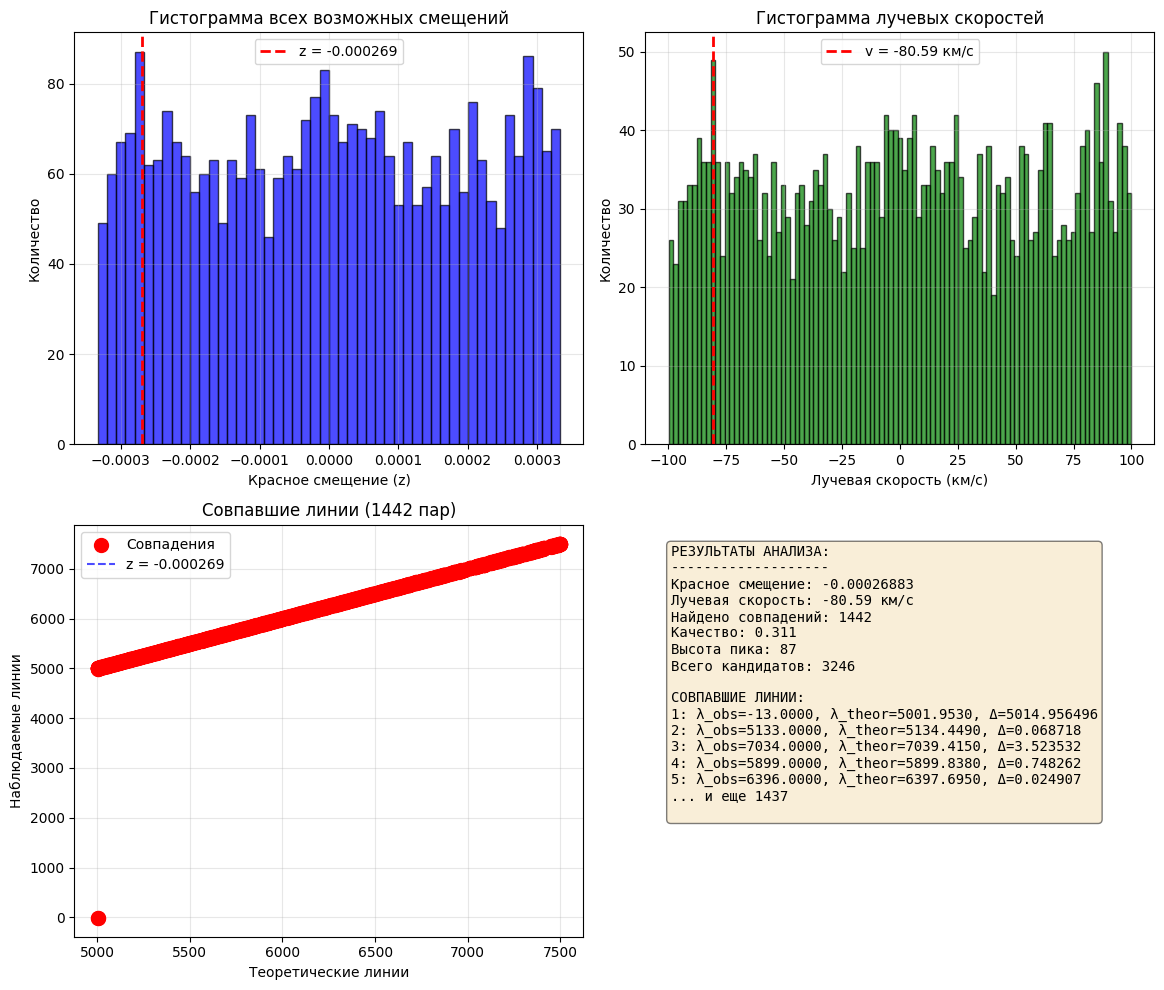

In [185]:
# 1. Подготовьте данные
observed = detect_lines  # Ваши наблюдаемые линии
theoretical = wavelenght_fit  # Теоретический список

# 2. Создайте объект
finder = SpectralShiftFinder(
    observed_lines=observed,
    theoretical_lines=theoretical,
    velocity_range=(-100, 100)  # Диапазон поиска в км/с
)

# 3. Найдите смещение
results = finder.find_shift_hough(
    bins=50,
    smoothing=0.1,
    min_peaks=3
)

# 4. Получите результаты
print(f"Красное смещение: {results['redshift']}")
print(f"Скорость: {results['velocity_km_s']} км/с")

# 5. Визуализируйте
finder.plot_results()